## Import Libraries

In [40]:
import pandas as pd 
import numpy as np 

import matplotlib.pyplot as plt 
import seaborn as sns 
import plotly.express as px 

from sklearn.preprocessing import MinMaxScaler,StandardScaler,RobustScaler
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
from sklearn.model_selection import train_test_split, cross_val_score

from sklearn.metrics import accuracy_score , confusion_matrix , classification_report 

In [2]:
df_train= pd.read_csv("D:\Advanced AI\ML assimgent 1\Credit card/train_data.csv")

df_test=pd.read_csv("D:\Advanced AI\ML assimgent 1\Credit card/test_data.csv")

df_train

<>:1: SyntaxWarning: invalid escape sequence '\A'
<>:3: SyntaxWarning: invalid escape sequence '\A'
<>:1: SyntaxWarning: invalid escape sequence '\A'
<>:3: SyntaxWarning: invalid escape sequence '\A'
C:\Users\amral\AppData\Local\Temp\ipykernel_21240\3381701155.py:1: SyntaxWarning: invalid escape sequence '\A'
  df_train= pd.read_csv("D:\Advanced AI\ML assimgent 1\Credit card/train_data.csv")
C:\Users\amral\AppData\Local\Temp\ipykernel_21240\3381701155.py:3: SyntaxWarning: invalid escape sequence '\A'
  df_test=pd.read_csv("D:\Advanced AI\ML assimgent 1\Credit card/test_data.csv")


,ID,Gender,Has a car,Has a property,Children count,Income,Employment status,Education level,Marital status,Dwelling,Age,Employment length,Has a mobile phone,Has a work phone,Has a phone,Has an email,Job title,Family member count,Account age,Is high risk
0,5037048,M,Y,Y,0,135000.0,Working,Secondary / secondary special,Married,With parents,-16271,-3111,1,0,0,0,Core staff,2.0,-17.0,0
1,5044630,F,Y,N,1,135000.0,Commercial associate,Higher education,Single / not married,House / apartment,-10130,-1651,1,0,0,0,Accountants,2.0,-1.0,0
2,5079079,F,N,Y,2,180000.0,Commercial associate,Secondary / secondary special,Married,House / apartment,-12821,-5657,1,0,0,0,Laborers,4.0,-38.0,0
3,5112872,F,Y,Y,0,360000.0,Commercial associate,Higher education,Single / not married,House / apartment,-20929,-2046,1,0,0,1,Managers,1.0,-11.0,0
4,5105858,F,N,N,0,270000.0,Working,Secondary / secondary special,Separated,House / apartment,-16207,-515,1,0,1,0,NaN,1.0,-41.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29160,5067139,F,N,Y,0,112500.0,Pensioner,Secondary / secondary special,Single / not married,House / apartment,-23400,365243,1,0,1,1,NaN,1.0,-5.0,0
29161,5029193,F,N,Y,1,135000.0,Commercial associate,Secondary / secondary special,Married,House / apartment,-15532,-8256,1,0,0,0,Core staff,3.0,-24.0,0
29162,5047710,F,N,Y,0,76500.0,Working,Secondary / secondary special,Married,House / apartment,-17782,-3291,1,1,1,0,Managers,2.0,-29.0,0
29163,5009886,F,N,Y,0,157500.0,Pensioner,Secondary / secondary special,Civil marriage,House / apartment,-21635,365243,1,0,1,0,NaN,2.0,-37.0,0


In [3]:
df_train.columns.to_list()

['ID',
 'Gender',
 'Has a car',
 'Has a property',
 'Children count',
 'Income',
 'Employment status',
 'Education level',
 'Marital status',
 'Dwelling',
 'Age',
 'Employment length',
 'Has a mobile phone',
 'Has a work phone',
 'Has a phone',
 'Has an email',
 'Job title',
 'Family member count',
 'Account age',
 'Is high risk']

In [4]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29165 entries, 0 to 29164
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   29165 non-null  int64  
 1   Gender               29165 non-null  object 
 2   Has a car            29165 non-null  object 
 3   Has a property       29165 non-null  object 
 4   Children count       29165 non-null  int64  
 5   Income               29165 non-null  float64
 6   Employment status    29165 non-null  object 
 7   Education level      29165 non-null  object 
 8   Marital status       29165 non-null  object 
 9   Dwelling             29165 non-null  object 
 10  Age                  29165 non-null  int64  
 11  Employment length    29165 non-null  int64  
 12  Has a mobile phone   29165 non-null  int64  
 13  Has a work phone     29165 non-null  int64  
 14  Has a phone          29165 non-null  int64  
 15  Has an email         29165 non-null 

In [5]:
df_train.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,29165.0,5.078232e+06,41824.000708,5008804.0,5042047.0,5074666.0,5114629.0,5150485.0
Children count,29165.0,4.307903e-01,0.741882,0.0,0.0,0.0,1.0,19.0
Income,29165.0,1.868904e+05,101409.644327,27000.0,121500.0,157500.0,225000.0,1575000.0
Age,29165.0,-1.597948e+04,4202.997485,-25152.0,-19444.0,-15565.0,-12475.0,-7705.0
Employment length,29165.0,5.925776e+04,137655.883458,-15713.0,-3153.0,-1557.0,-412.0,365243.0
Has a mobile phone,29165.0,1.000000e+00,0.000000,1.0,1.0,1.0,1.0,1.0
Has a work phone,29165.0,2.243100e-01,0.417134,0.0,0.0,0.0,0.0,1.0
Has a phone,29165.0,2.949769e-01,0.456040,0.0,0.0,0.0,1.0,1.0
Has an email,29165.0,9.027944e-02,0.286587,0.0,0.0,0.0,0.0,1.0
Family member count,29165.0,2.197531e+00,0.912189,1.0,2.0,2.0,3.0,20.0


In [6]:
df_train.isnull().sum()

ID                        0
Gender                    0
Has a car                 0
Has a property            0
Children count            0
Income                    0
Employment status         0
Education level           0
Marital status            0
Dwelling                  0
Age                       0
Employment length         0
Has a mobile phone        0
Has a work phone          0
Has a phone               0
Has an email              0
Job title              9027
Family member count       0
Account age               0
Is high risk              0
dtype: int64

In [7]:
df_train.duplicated().sum()

np.int64(0)

In [8]:
df_train["Job title"].value_counts()

Job title
Laborers                 5004
Core staff               2866
Sales staff              2773
Managers                 2422
Drivers                  1722
High skill tech staff    1133
Accountants               998
Medicine staff            956
Cooking staff             521
Security staff            464
Cleaning staff            425
Private service staff     287
Low-skill Laborers        138
Waiters/barmen staff      127
Secretaries               122
HR staff                   72
Realty agents              60
IT staff                   48
Name: count, dtype: int64

In [9]:
df_train.drop(columns=["ID", "Has a mobile phone", "Has a work phone", "Has a phone", "Has an email"],inplace= True)

df_test.drop(columns=["ID", "Has a mobile phone", "Has a work phone", "Has a phone", "Has an email"],inplace= True)

df_train

,Gender,Has a car,Has a property,Children count,Income,Employment status,Education level,Marital status,Dwelling,Age,Employment length,Job title,Family member count,Account age,Is high risk
0,M,Y,Y,0,135000.0,Working,Secondary / secondary special,Married,With parents,-16271,-3111,Core staff,2.0,-17.0,0
1,F,Y,N,1,135000.0,Commercial associate,Higher education,Single / not married,House / apartment,-10130,-1651,Accountants,2.0,-1.0,0
2,F,N,Y,2,180000.0,Commercial associate,Secondary / secondary special,Married,House / apartment,-12821,-5657,Laborers,4.0,-38.0,0
3,F,Y,Y,0,360000.0,Commercial associate,Higher education,Single / not married,House / apartment,-20929,-2046,Managers,1.0,-11.0,0
4,F,N,N,0,270000.0,Working,Secondary / secondary special,Separated,House / apartment,-16207,-515,NaN,1.0,-41.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29160,F,N,Y,0,112500.0,Pensioner,Secondary / secondary special,Single / not married,House / apartment,-23400,365243,NaN,1.0,-5.0,0
29161,F,N,Y,1,135000.0,Commercial associate,Secondary / secondary special,Married,House / apartment,-15532,-8256,Core staff,3.0,-24.0,0
29162,F,N,Y,0,76500.0,Working,Secondary / secondary special,Married,House / apartment,-17782,-3291,Managers,2.0,-29.0,0
29163,F,N,Y,0,157500.0,Pensioner,Secondary / secondary special,Civil marriage,House / apartment,-21635,365243,NaN,2.0,-37.0,0


In [10]:
df_train.columns.to_list()

['Gender',
 'Has a car',
 'Has a property',
 'Children count',
 'Income',
 'Employment status',
 'Education level',
 'Marital status',
 'Dwelling',
 'Age',
 'Employment length',
 'Job title',
 'Family member count',
 'Account age',
 'Is high risk']

In [11]:
# labelencoder = LabelEncoder()

# columns_to_encode = ["Employment status", "Education level", "Marital status", "Dwelling", "Job title"]

# for column in columns_to_encode :
    
#     df_train[column] = labelencoder.fit_transform(df_train[column]) 
#     df_test[column] = labelencoder.fit_transform(df_test[column]) 

In [12]:
# colmns = df_train.select_dtypes(include=['number'])
# corr = colmns.corr()
# plt.figure(figsize=(12, 6))  
# sns.heatmap(corr, annot=True, fmt=".2f", cmap="viridis", linewidths=0.5)

## Fill in the Nan values

In [13]:
mode_value = df_train["Job title"].mode()[0]

df_train["Job title"].fillna(mode_value, inplace=True)

C:\Users\amral\AppData\Local\Temp\ipykernel_21240\3464127968.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_train["Job title"].fillna(mode_value, inplace=True)


In [14]:
# colmns = df_train.select_dtypes(include=['number'])
# corr = colmns.corr()
# plt.figure(figsize=(12, 6))  
# sns.heatmap(corr, annot=True, fmt=".2f", cmap="viridis", linewidths=0.5)

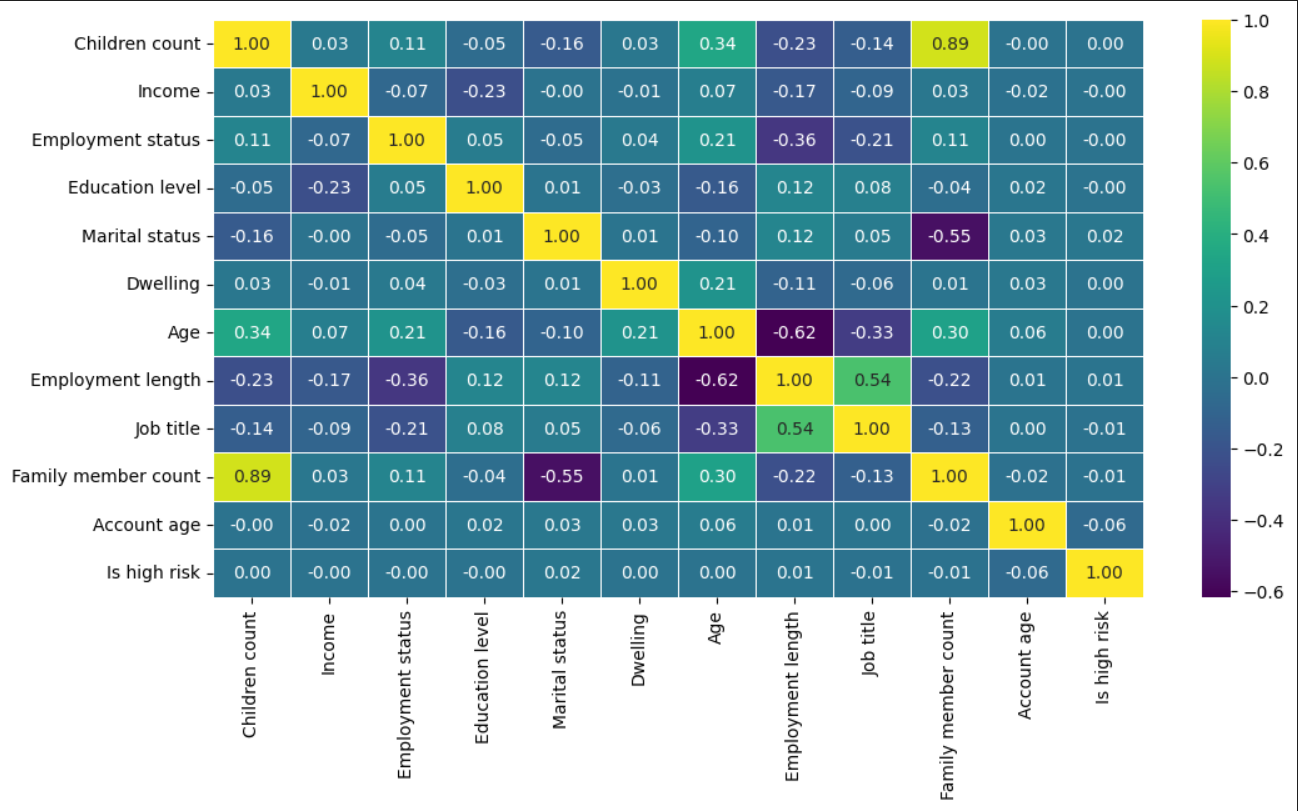

In [15]:
from IPython.display import Image, display
display(Image(filename=r"C:\Users\amral\OneDrive\Pictures\Screenshots\Screenshot 2025-12-09 011241.png", width=900, height=600))


### - Analysis of Correlation: 'Job Title' vs. 'Is High Risk'
Justification for My Imputation Strategy in 'Job Title'

After reviewing the correlation matrix, I noticed that the correlation coefficient between the Job title column and my target variable, Is high risk, is -0.01.

This value is practically zero, which tells me that a person's job title has almost no predictive power in determining if they will be classified as "high risk."

For this reason, I've decided to use a simple method to fill the missing values in this column: replacing them with the most frequent value (the mode). Since the feature itself isn't influential, there's no need to invest significant effort in finding the exact true values. The difference between the imputed mode and the actual value will have a negligible impact on my final model's performance anyway.

In [16]:
df_train.isnull().sum()

Gender                 0
Has a car              0
Has a property         0
Children count         0
Income                 0
Employment status      0
Education level        0
Marital status         0
Dwelling               0
Age                    0
Employment length      0
Job title              0
Family member count    0
Account age            0
Is high risk           0
dtype: int64

In [17]:
numeric_columns_with_null = df_train.select_dtypes(include=['number']).columns[df_train.select_dtypes(include=['number']).any()]
numeric_columns_with_null

Index(['Children count', 'Income', 'Age', 'Employment length',
       'Family member count', 'Account age', 'Is high risk'],
      dtype='object')

In [18]:
object_columns_with_null = df_train.select_dtypes(exclude=['number']).columns[df_train.select_dtypes(exclude=['number']).any()]
object_columns_with_null

Index(['Gender', 'Has a car', 'Has a property', 'Employment status',
       'Education level', 'Marital status', 'Dwelling', 'Job title'],
      dtype='object')

## EDA

In [19]:

px.scatter(x=df_train['Age'],y=df_train['Income'],color=df_train['Gender'])

<Axes: xlabel='Family member count', ylabel='Income'>

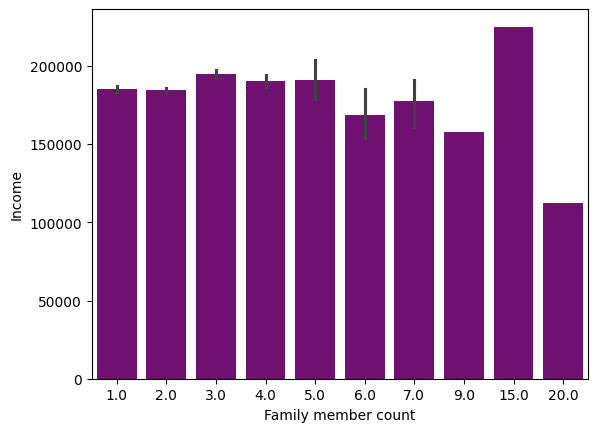

In [20]:
sns.barplot(x=df_train['Family member count'],y=df_train["Income"],color='purple')

<Axes: xlabel='Is high risk', ylabel='count'>

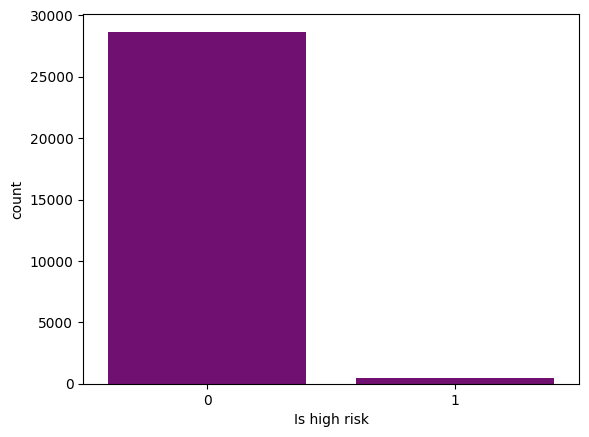

In [21]:
sns.countplot(data=df_train,x="Is high risk",color="purple")

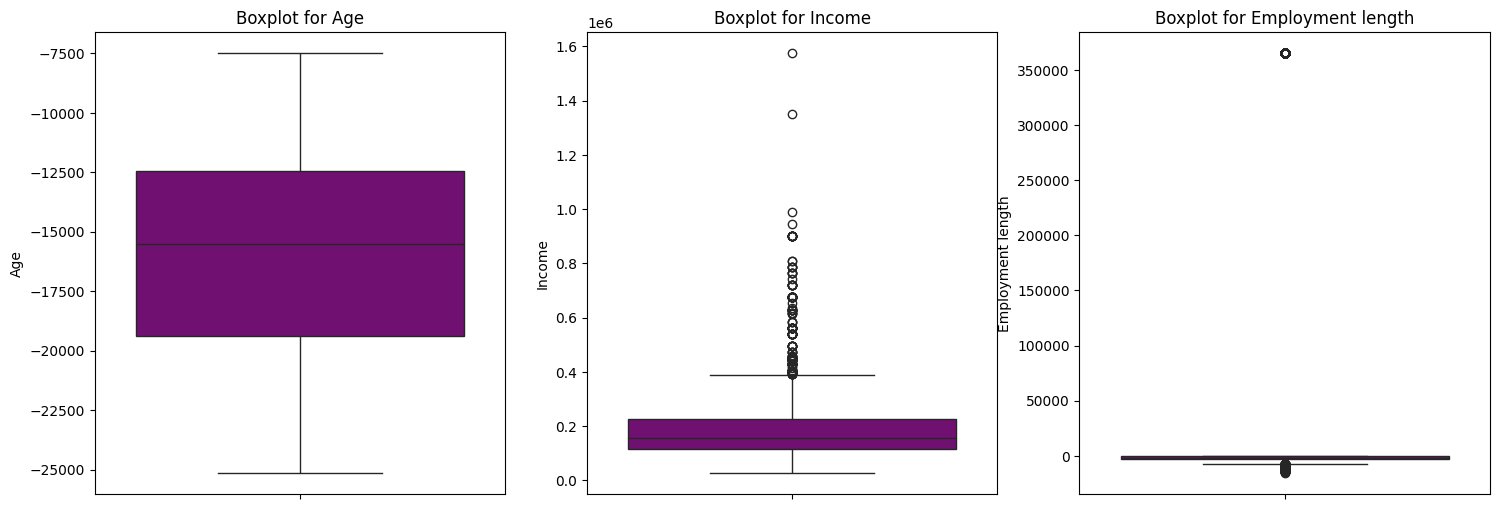

In [22]:
cols=['Age',"Income","Employment length"]
plt.figure(figsize=(18,6))
for i, col in enumerate(cols, 1):
    plt.subplot(1, 3, i)    # صف واحد - 3 أعمدة
    sns.boxplot(y=df_test[col],color="purple")
    plt.title(f"Boxplot for {col}")

## Preprocessing 

### - Scaling

I used Robust Scaling for preprocessing because the Income column contains a large number of extreme outliers.

Unlike StandardScaler or MinMaxScaler, the RobustScaler is not affected by outliers, as it uses the median and the IQR (Interquartile Range) instead of the mean and standard deviation.

This helps keep the scaled data more stable and prevents the outliers from distorting the distribution.

In [23]:
r_scaler= RobustScaler()
# columns with outliers
df_train["Income"] = r_scaler.fit_transform(df_train[["Income"]])
df_test["Income"] = r_scaler.fit_transform(df_test[["Income"]])


m_scaler=MinMaxScaler()

df_train["Employment length"] = m_scaler.fit_transform(df_train[["Employment length"]])
df_test["Employment length"] = m_scaler.fit_transform(df_test[["Employment length"]]) 

df_train["Age"] = m_scaler.fit_transform(df_train[["Age"]])
df_test["Age"] = m_scaler.fit_transform(df_test[["Age"]])



In [27]:
# Because of the negative
df_train['Income'] = df_train['Income'].abs()
df_test['Income'] = df_test['Income'].abs()


In [28]:
df_train

,Gender,Has a car,Has a property,Children count,Income,Employment status,Education level,Marital status,Dwelling,Age,Employment length,Job title,Family member count,Account age,Is high risk
0,M,Y,Y,0,0.217391,Working,Secondary / secondary special,Married,With parents,0.509027,0.033080,Core staff,2.0,-17.0,0
1,F,Y,N,1,0.217391,Commercial associate,Higher education,Single / not married,House / apartment,0.861008,0.036912,Accountants,2.0,-1.0,0
2,F,N,Y,2,0.217391,Commercial associate,Secondary / secondary special,Married,House / apartment,0.706769,0.026397,Laborers,4.0,-38.0,0
3,F,Y,Y,0,1.956522,Commercial associate,Higher education,Single / not married,House / apartment,0.242047,0.035876,Managers,1.0,-11.0,0
4,F,N,N,0,1.086957,Working,Secondary / secondary special,Separated,House / apartment,0.512696,0.039894,Laborers,1.0,-41.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29160,F,N,Y,0,0.434783,Pensioner,Secondary / secondary special,Single / not married,House / apartment,0.100418,1.000000,Laborers,1.0,-5.0,0
29161,F,N,Y,1,0.217391,Commercial associate,Secondary / secondary special,Married,House / apartment,0.551384,0.019574,Core staff,3.0,-24.0,0
29162,F,N,Y,0,0.782609,Working,Secondary / secondary special,Married,House / apartment,0.422422,0.032607,Managers,2.0,-29.0,0
29163,F,N,Y,0,0.000000,Pensioner,Secondary / secondary special,Civil marriage,House / apartment,0.201582,1.000000,Laborers,2.0,-37.0,0


### - Encoding

In [31]:
df_train["Education level"].value_counts()


Education level
Secondary / secondary special    19803
Higher education                  7910
Incomplete higher                 1129
Lower secondary                    298
Academic degree                     25
Name: count, dtype: int64

In [36]:
labelencoder = LabelEncoder()

# تحديد الأعمدة النصية (categorical)
categorical_cols = df_train.select_dtypes(include=['object']).columns

for col in categorical_cols:
    df_train[col] = labelencoder.fit_transform(df_train[col])
    
df_train

,Gender,Has a car,Has a property,Children count,Income,Employment status,Education level,Marital status,Dwelling,Age,Employment length,Job title,Family member count,Account age,Is high risk
0,1,1,1,0,0.217391,4,4,1,5,0.509027,0.033080,3,2.0,-17.0,0
1,0,1,0,1,0.217391,0,1,3,1,0.861008,0.036912,0,2.0,-1.0,0
2,0,0,1,2,0.217391,0,4,1,1,0.706769,0.026397,8,4.0,-38.0,0
3,0,1,1,0,1.956522,0,1,3,1,0.242047,0.035876,10,1.0,-11.0,0
4,0,0,0,0,1.086957,4,4,2,1,0.512696,0.039894,8,1.0,-41.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29160,0,0,1,0,0.434783,1,4,3,1,0.100418,1.000000,8,1.0,-5.0,0
29161,0,0,1,1,0.217391,0,4,1,1,0.551384,0.019574,3,3.0,-24.0,0
29162,0,0,1,0,0.782609,4,4,1,1,0.422422,0.032607,10,2.0,-29.0,0
29163,0,0,1,0,0.000000,1,4,0,1,0.201582,1.000000,8,2.0,-37.0,0


In [51]:
x = df_train.drop('Is high risk', axis=1)
y = df_train['Is high risk']

In [52]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

## Modeling 

In [56]:
from sklearn.linear_model import LogisticRegression
model_lg=LogisticRegression()
scores=cross_val_score(model_lg,x_train,y_train,cv=5,scoring='r2')

print("R2 scores for each fold:",scores)
print("Average R2:", scores.mean())

d:\Python file\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning:

lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression

d:\Python file\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning:

lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver option

R2 scores for each fold: [-0.01810646 -0.01810646 -0.01788831 -0.01788831 -0.01811041]
Average R2: -0.018019987365097155


d:\Python file\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning:

lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression

d:\Python file\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning:

lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver option

In [57]:
model_lg.fit(x_train,y_train)

d:\Python file\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning:

lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression



,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [58]:
y_pred=model_lg.predict(x_test)

In [59]:
accuracy_score(y_test,y_pred)

0.9852563003600205

In [60]:
from sklearn.ensemble import RandomForestClassifier

model_Rf=RandomForestClassifier()
scores = cross_val_score(model_Rf,x, y, cv=5, scoring='r2') 

print("R2 scores:", scores)
print("Average R2:", scores.mean())

R2 scores: [-0.04809166 -0.08866388 -0.0988383  -0.13953602 -0.08866388]
Average R2: -0.09275874704685302


In [61]:
model_Rf.fit(x_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [62]:
y_pred_rf=model_Rf.predict(x_test)

In [63]:
accuracy_score(y_test,y_pred_rf)

0.9837133550488599

In [64]:
from sklearn.svm import SVC

model_svc=SVC()
scores = cross_val_score(model_svc,x, y, cv=5, scoring='r2') 

print("R2 scores:", scores)
print("Average R2:", scores.mean())

R2 scores: [-0.01726543 -0.01744287 -0.01744287 -0.01744287 -0.01744287]
Average R2: -0.017407386518951507


In [65]:
model_svc.fit(x_train,y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [66]:
y_perd_svc=model_svc.predict(x_test)

In [67]:
accuracy_score(y_test,y_perd_svc)

0.9852563003600205